# Assignment 3
### Due 9/23. Do four of five.

In [99]:
import pandas as pd 
import numpy as np
import os

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [86]:
# load the Ames prices dataset into a pandas DataFrame

ames_df = pd.read_csv("/Users/khansaamaa/Downloads/data/ames_prices.csv")
ames_df.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [101]:
print(os.path.exists("/Users/khansaamaa/Downloads/data/ames_codebook.txt"))

True


In [ ]:
# Open and read the file

with open('/Users/khansaamaa/Downloads/data/ames_codebook.txt', 'r', encoding='latin1') as file:
    lines = file.readlines()

In [ ]:
# Print the first few lines

for line in lines[:10]:
    print(line.strip())

NAME: AmesHousing.txt
TYPE: Population
SIZE: 2930 observations, 82 variables
ARTICLE TITLE: Ames Iowa: Alternative to the Boston Housing Data Set

DESCRIPTIVE ABSTRACT: Data set contains information from the Ames Assessors Office used in computing assessed values for individual residential properties sold in Ames, IA from 2006 to 2010.

SOURCES:
Ames, Iowa Assessors Office



In [106]:
# Open and read the entire file
with open('/Users/khansaamaa/Downloads/data/ames_codebook.txt', 'r',encoding='latin1') as file:
    content = file.read()

# Print the full content
print(content)  

NAME: AmesHousing.txt
TYPE: Population
SIZE: 2930 observations, 82 variables
ARTICLE TITLE: Ames Iowa: Alternative to the Boston Housing Data Set

DESCRIPTIVE ABSTRACT: Data set contains information from the Ames Assessors Office used in computing assessed values for individual residential properties sold in Ames, IA from 2006 to 2010.

SOURCES: 
Ames, Iowa Assessors Office 

VARIABLE DESCRIPTIONS:
Tab characters are used to separate variables in the data file. The data has 82 columns which include 23 nominal, 23 ordinal, 14 discrete, and 20 continuous variables (and 2 additional observation identifiers).

Order (Discrete): Observation number

PID (Nominal): Parcel identification number  - can be used with city web site for parcel review. 

MS SubClass (Nominal): Identifies the type of dwelling involved in the sale.	

       020	1-STORY 1946 & NEWER ALL STYLES
       030	1-STORY 1945 & OLDER
       040	1-STORY W/FINISHED ATTIC ALL AGES
       045	1-1/2 STORY - UNFINISHED ALL AGES
   

In [87]:
# list all columns in the DataFrame
ames_df.columns.tolist()

['Order',
 'PID',
 'area',
 'price',
 'MS.SubClass',
 'MS.Zoning',
 'Lot.Frontage',
 'Lot.Area',
 'Street',
 'Alley',
 'Lot.Shape',
 'Land.Contour',
 'Utilities',
 'Lot.Config',
 'Land.Slope',
 'Neighborhood',
 'Condition.1',
 'Condition.2',
 'Bldg.Type',
 'House.Style',
 'Overall.Qual',
 'Overall.Cond',
 'Year.Built',
 'Year.Remod.Add',
 'Roof.Style',
 'Roof.Matl',
 'Exterior.1st',
 'Exterior.2nd',
 'Mas.Vnr.Type',
 'Mas.Vnr.Area',
 'Exter.Qual',
 'Exter.Cond',
 'Foundation',
 'Bsmt.Qual',
 'Bsmt.Cond',
 'Bsmt.Exposure',
 'BsmtFin.Type.1',
 'BsmtFin.SF.1',
 'BsmtFin.Type.2',
 'BsmtFin.SF.2',
 'Bsmt.Unf.SF',
 'Total.Bsmt.SF',
 'Heating',
 'Heating.QC',
 'Central.Air',
 'Electrical',
 'X1st.Flr.SF',
 'X2nd.Flr.SF',
 'Low.Qual.Fin.SF',
 'Bsmt.Full.Bath',
 'Bsmt.Half.Bath',
 'Full.Bath',
 'Half.Bath',
 'Bedroom.AbvGr',
 'Kitchen.AbvGr',
 'Kitchen.Qual',
 'TotRms.AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace.Qu',
 'Garage.Type',
 'Garage.Yr.Blt',
 'Garage.Finish',
 'Garage.Cars',
 'Ga

In [88]:
numerical_cols = ames_df.select_dtypes(include=np.number).columns
print(numerical_cols)

Index(['Order', 'PID', 'area', 'price', 'MS.SubClass', 'Lot.Frontage',
       'Lot.Area', 'Overall.Qual', 'Overall.Cond', 'Year.Built',
       'Year.Remod.Add', 'Mas.Vnr.Area', 'BsmtFin.SF.1', 'BsmtFin.SF.2',
       'Bsmt.Unf.SF', 'Total.Bsmt.SF', 'X1st.Flr.SF', 'X2nd.Flr.SF',
       'Low.Qual.Fin.SF', 'Bsmt.Full.Bath', 'Bsmt.Half.Bath', 'Full.Bath',
       'Half.Bath', 'Bedroom.AbvGr', 'Kitchen.AbvGr', 'TotRms.AbvGrd',
       'Fireplaces', 'Garage.Yr.Blt', 'Garage.Cars', 'Garage.Area',
       'Wood.Deck.SF', 'Open.Porch.SF', 'Enclosed.Porch', 'X3Ssn.Porch',
       'Screen.Porch', 'Pool.Area', 'Misc.Val', 'Mo.Sold', 'Yr.Sold'],
      dtype='object')


In [89]:
categorical_cols = ames_df.select_dtypes(include='category').columns

print(categorical_cols)

Index([], dtype='object')


In [90]:
# Select object-type columns
object_cols = ames_df.select_dtypes(include='object').columns
print("\nObject-type columns (potential categorical):")
print(object_cols)


Object-type columns (potential categorical):
Index(['MS.Zoning', 'Street', 'Alley', 'Lot.Shape', 'Land.Contour',
       'Utilities', 'Lot.Config', 'Land.Slope', 'Neighborhood', 'Condition.1',
       'Condition.2', 'Bldg.Type', 'House.Style', 'Roof.Style', 'Roof.Matl',
       'Exterior.1st', 'Exterior.2nd', 'Mas.Vnr.Type', 'Exter.Qual',
       'Exter.Cond', 'Foundation', 'Bsmt.Qual', 'Bsmt.Cond', 'Bsmt.Exposure',
       'BsmtFin.Type.1', 'BsmtFin.Type.2', 'Heating', 'Heating.QC',
       'Central.Air', 'Electrical', 'Kitchen.Qual', 'Functional',
       'Fireplace.Qu', 'Garage.Type', 'Garage.Finish', 'Garage.Qual',
       'Garage.Cond', 'Paved.Drive', 'Pool.QC', 'Fence', 'Misc.Feature',
       'Sale.Type', 'Sale.Condition'],
      dtype='object')


Based on the ames codebook, here are two categorical variables :

- Neighborhood: Physical locations within Ames city

- House.Style: Style of dwelling (e.g., 1Story, 2Story, etc.)

In [108]:
ames_df[['Neighborhood', 'House.Style']].isnull().sum()

Neighborhood    0
House.Style     0
dtype: int64

There are no null values in these columns

In [111]:
# Create a contingency table

contingency_table = pd.crosstab(ames_df['Neighborhood'], ames_df['House.Style'], margins=True)
contingency_table

House.Style,1.5Fin,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,All
Neighborhood,,,,,,,,,
Blmngtn,0,0,28,0,0,0,0,0,28
Blueste,0,0,3,0,0,7,0,0,10
BrDale,0,0,0,0,0,30,0,0,30
BrkSide,56,8,32,0,2,10,0,0,108
ClearCr,8,0,22,0,0,10,0,4,44
CollgCr,0,0,158,0,0,98,5,6,267
Crawfor,21,1,41,1,4,33,0,2,103
Edwards,43,0,102,0,1,24,13,11,194
Gilbert,1,0,26,0,0,119,0,19,165


In [112]:
# Example: Find top 3 neighborhoods with most 2Story homes

top_2story = contingency_table['2Story'].sort_values(ascending=False).head(3)
print(top_2story)

Neighborhood
All        873
Gilbert    119
CollgCr     98
Name: 2Story, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

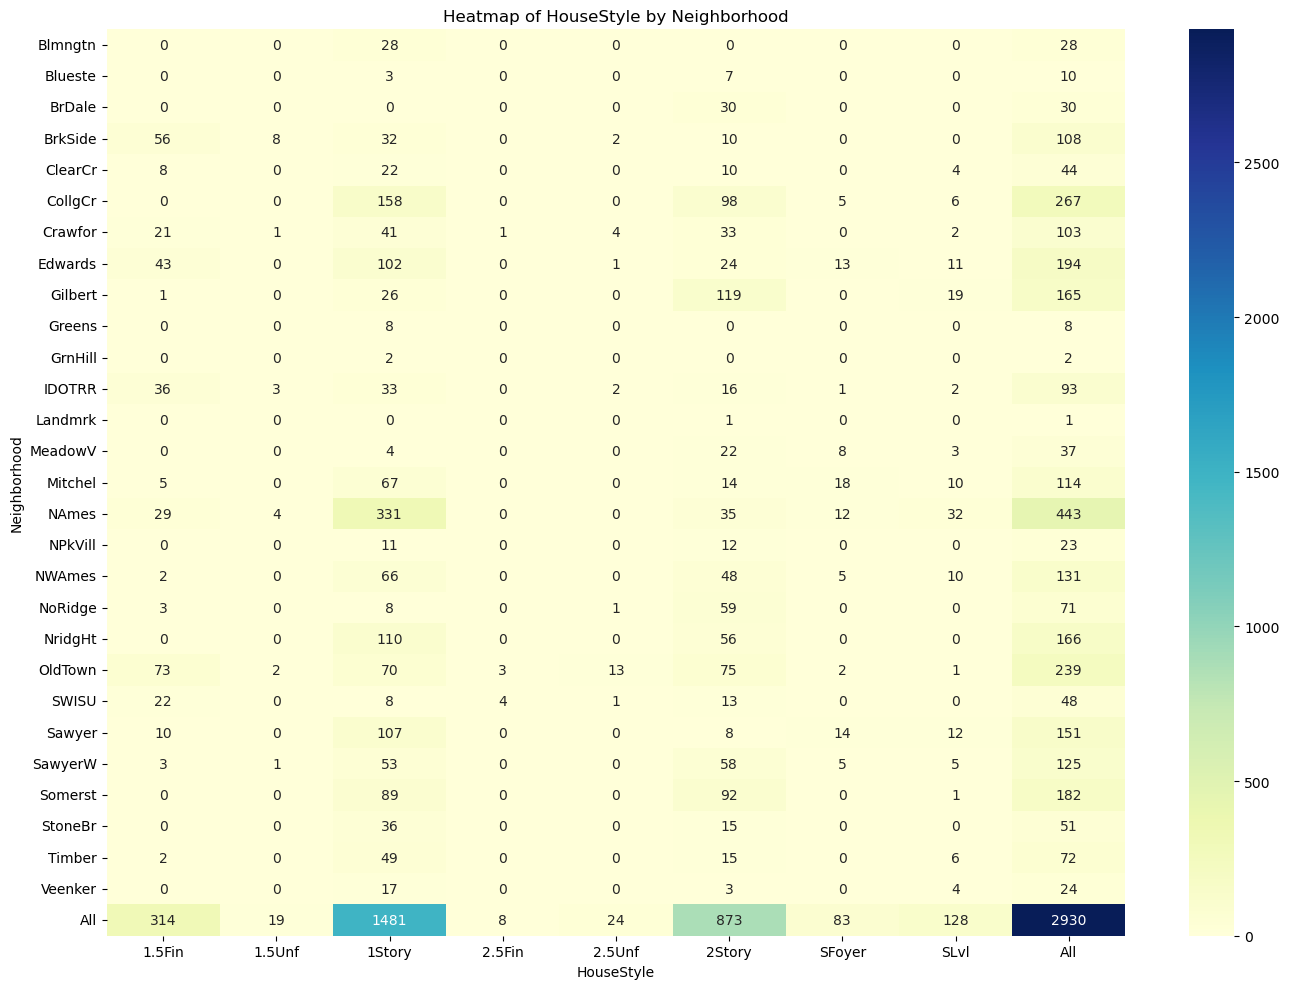

In [113]:
# heatmap of neighborhood vs house style

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(contingency_table, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Heatmap of HouseStyle by Neighborhood')
plt.xlabel('HouseStyle')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

##### Observations :

Neighborhoods Favoring Specific House Styles :

- Somerset, Northridge, and StoneBr tend to favor 2Story and 1Story homes, often with modern layouts.

- OldTown, Edwards, and SWISU show a higher concentration of 1.5Fin and 1Story homes, reflecting older architectural styles.

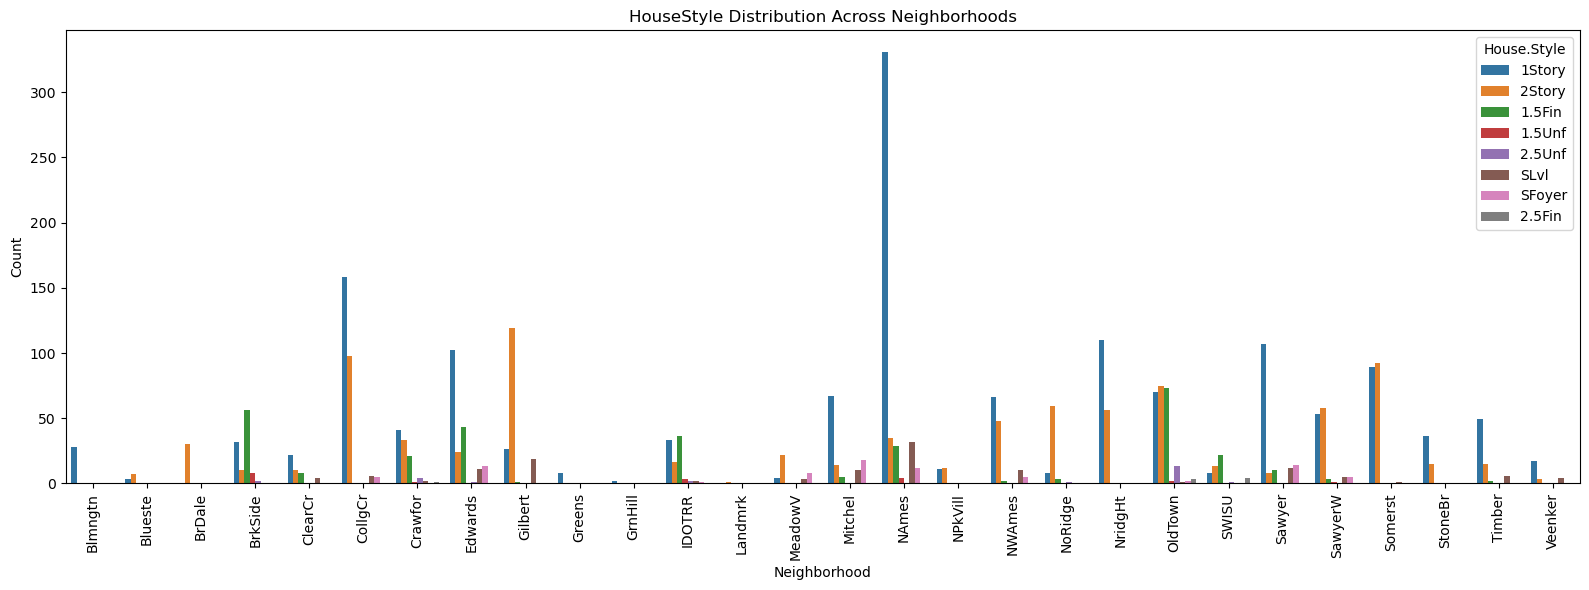

In [114]:
# Hourse.Style counts per Neighborhood

# Group and count
style_counts = ames_df.groupby(['Neighborhood', 'House.Style']).size().reset_index(name='Count')

# Plot
plt.figure(figsize=(16, 6))
sns.barplot(data=style_counts, x='Neighborhood', y='Count', hue='House.Style')
plt.xticks(rotation=90)
plt.title('HouseStyle Distribution Across Neighborhoods')
plt.tight_layout()
plt.show()

##### Observations :

- 2.5Fin and 2.5Unf styles are extremely rare across all neighborhoods.

- Some neighborhoods like Blueste or Landmrk might have only a handful of homes, making any style rare by count.

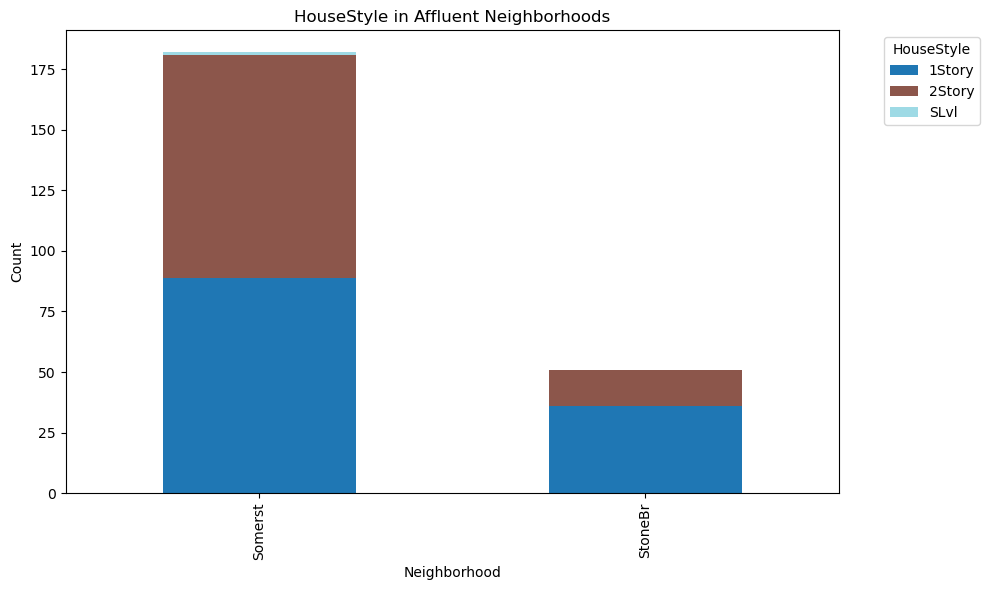

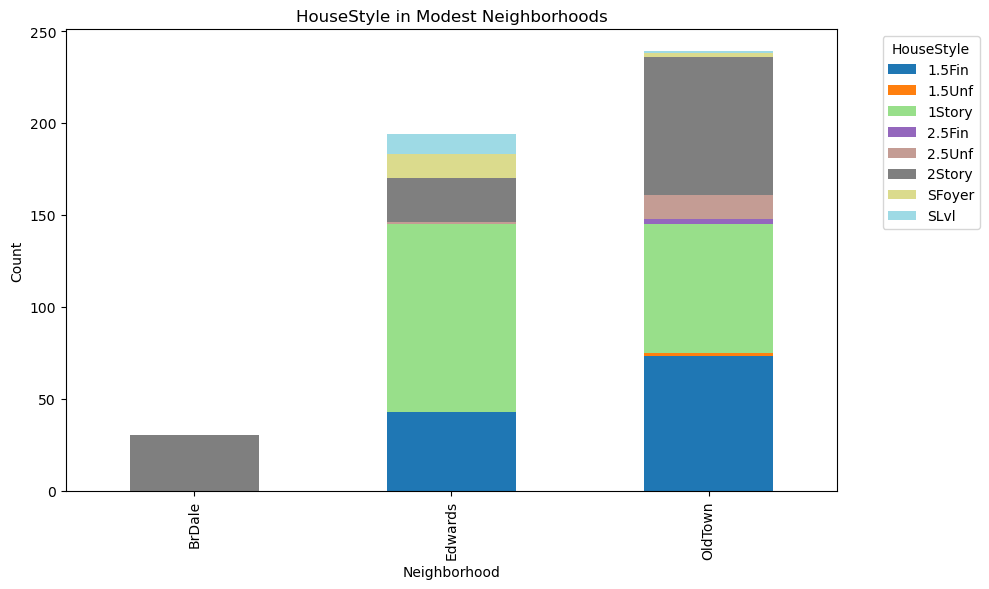

In [118]:
# Affluent vs. Modest Neighborhoods

affluent = ['StoneBr', 'Northridge', 'Somerst']
modest = ['OldTown', 'Edwards', 'BrDale']

# Filter and count
df_affluent = ames_df[ames_df['Neighborhood'].isin(affluent)]
df_modest = ames_df[ames_df['Neighborhood'].isin(modest)]

def stacked_bar(data, title):
    ct = pd.crosstab(data['Neighborhood'], data['House.Style'])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(title)
    plt.xlabel('Neighborhood')
    plt.ylabel('Count')
    plt.legend(title='HouseStyle', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

stacked_bar(df_affluent, 'HouseStyle in Affluent Neighborhoods')
stacked_bar(df_modest, 'HouseStyle in Modest Neighborhoods')

##### Observations:

- Affluent areas (e.g., Northridge, StoneBr, Somerst):
    - Dominated by 2Story, 1Story, and SFoyer homes.
    - These styles often correlate with larger lot sizes and newer construction.

- Modest areas (e.g., OldTown, Edwards, BrDale):
    - More likely to have 1.5Fin, 1Story, and SFoyer homes.
    - These styles reflect older, more compact housing stock.

In [117]:
# Rare Styles Across All Neighborhoods

# Count total occurrences of each style
rare_styles = ames_df['House.Style'].value_counts().sort_values().head(3)
print("Rare house styles:\n", rare_styles)

Rare house styles:
 House.Style
2.5Fin     8
1.5Unf    19
2.5Unf    24
Name: count, dtype: int64


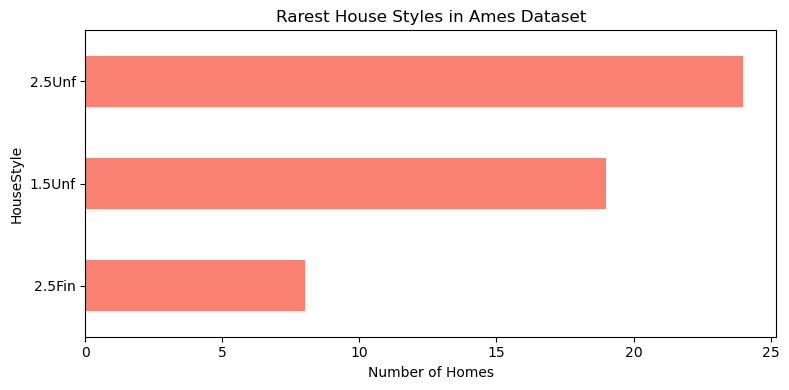

In [119]:
# Count occurrences of each HouseStyle
style_counts = ames_df['House.Style'].value_counts().sort_values()

# Select the 3 rarest styles
rare_styles = style_counts.head(3)

# Plot
plt.figure(figsize=(8, 4))
rare_styles.plot(kind='barh', color='salmon')
plt.title('Rarest House Styles in Ames Dataset')
plt.xlabel('Number of Homes')
plt.ylabel('HouseStyle')
plt.tight_layout()
plt.show()

2.
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the nhanes_meta_17_18.csv file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric conditional on your categorical 
- Discuss any interesting patterns (or lack of one) that you observe

In [121]:
# Load the dataset
nhanes_df = pd.read_csv('/Users/khansaamaa/Downloads/data/nhanes_data_17_18.csv')

# Preview the data
nhanes_df.head()

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_61546/2354403309.py:2: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes_df = pd.read_csv('/Users/khansaamaa/Downloads/data/nhanes_data_17_18.csv')


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Choose a Categorical and Numeric Variable

- Categorical: GeneralHealthCondition 

- Numeric: BodyMassIndexKgm2

In [122]:
# check the missing values in the selected columns
nhanes_df[['GeneralHealthCondition', 'BodyMassIndexKgm2']].isnull().sum()

GeneralHealthCondition    2402
BodyMassIndexKgm2          361
dtype: int64

In [123]:
# Drop missing values in either column

df_clean = nhanes_df[['GeneralHealthCondition', 'BodyMassIndexKgm2']].dropna()

df_clean

,GeneralHealthCondition,BodyMassIndexKgm2
2,Good,31.7
3,Very good,21.5
4,Good,18.1
5,Good,23.7
7,Very good,21.3
...,...,...
8361,Very good,20.0
8362,Fair or,35.8
8363,Good,26.1
8364,Very good,45.6


In [124]:
# summary statistics
df_clean.groupby('GeneralHealthCondition')['BodyMassIndexKgm2'].describe()

,count,mean,std,min,25%,50%,75%,max
GeneralHealthCondition,,,,,,,,
Excellent,611.0,25.291489,5.706559,13.8,21.400,24.3,28.1,57.3
Fair or,1152.0,31.719358,8.030610,15.0,26.100,30.8,36.1,72.6
Good,2425.0,29.600948,7.480121,13.2,24.500,28.7,33.5,86.2
Poor?,170.0,34.252353,10.318606,14.9,28.275,33.3,37.7,84.4
Very good,1534.0,26.814342,6.154614,14.6,22.600,26.1,30.1,57.7


In [125]:
# Compute contingency table

contingency_table = pd.crosstab(
    df_clean['GeneralHealthCondition'],
    df_clean['BodyMassIndexKgm2'],
    margins=True  # Adds row and column totals
)

print(contingency_table)

BodyMassIndexKgm2       13.2  13.8  14.6  14.7  14.8  14.9  15.0  15.1  15.2  \
GeneralHealthCondition                                                         
Excellent                  0     1     0     1     1     0     0     0     0   
Fair or                    0     0     0     0     0     0     1     0     0   
Good                       1     0     0     0     0     0     0     0     1   
Poor?                      0     0     0     0     0     1     0     1     0   
Very good                  0     0     1     0     1     0     0     2     0   
All                        1     1     1     1     2     1     1     3     1   

BodyMassIndexKgm2       15.3  ...  64.7  65.3  66.2  67.7  68.2  72.6  74.8  \
GeneralHealthCondition        ...                                             
Excellent                  1  ...     0     0     0     0     0     0     0   
Fair or                    0  ...     0     1     0     1     1     1     0   
Good                       0  ...     1    

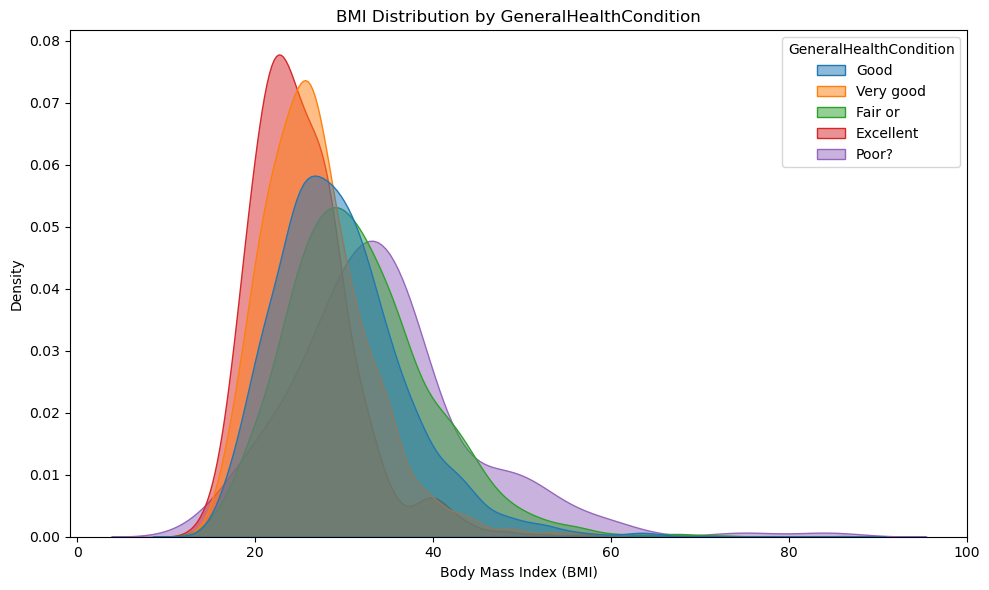

In [126]:
# Kernel Density Plot


plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='BodyMassIndexKgm2', hue='GeneralHealthCondition', fill=True, common_norm=False, alpha=0.5)
plt.title('BMI Distribution by GeneralHealthCondition')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

#### Observations :


- Individuals reporting “Excellent” health tend to have lower BMI values, with a sharp peak around the healthy range (typically 18.5–24.9).

- As self-reported health declines from “Very good” to “Fair” to “Poor?”, the BMI distribution shifts rightward, indicating higher BMI values.

- The “Poor?” category shows a flatter, wider distribution, suggesting more variability in BMI — including a significant tail into the obese range (>30).

- This could reflect a mix of chronic conditions, mobility limitations, or metabolic issues that correlate with elevated BMI.

- While all curves overlap to some extent, the mode (peak density) of each group shifts noticeably.

- The “Good” and “Fair” groups sit in the middle, with moderate BMI values and broader distributions than “Excellent.”

- The transition from “Excellent” to “Very good” shows a modest BMI increase.

- But the jump from “Fair” to “Poor?” is more dramatic — suggesting that BMI may be more strongly associated with perceived health at the lower end of the health spectrum.

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.x
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

In [ ]:
# Python class implementation

import numpy as np
from scipy.stats import norm


In [141]:
# Implementing the LCLS / Nadaraya-Watson Estimator

class NadarayaWatsonEstimator:
    def __init__(self, x, y, kernel='gaussian'):
        
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        
        self.n = len(x)
        
        self.kernel = self._get_kernel(kernel)
        
        self.h = self._silverman_bandwidth()


    def _get_kernel(self, name):
        if name == 'gaussian':
            return lambda u: norm.pdf(u)
        else:
            raise ValueError("Unsupported kernel")

    def _silverman_bandwidth(self):
        std_x = np.std(self.x, ddof=1)
        return 1.06 * std_x * self.n ** (-1/5)

    def predict(self, z):
        z = np.asarray(z)
        estimates = []
        
        for zi in z:
            weights = self.kernel((zi - self.x) / self.h)
            
            numerator = np.sum(weights * self.y)
            denominator = np.sum(weights)
            
            estimates.append(numerator / denominator if denominator != 0 else np.nan)
       
        return np.array(estimates)

In [ ]:
# apply the estimator to Ames data

df = ames_df[['TotRms.AbvGrd', 'price']].dropna()

x = df['TotRms.AbvGrd'].values
y = df['price'].values

In [143]:
# Fit estimator
nw = NadarayaWatsonEstimator(df['TotRms.AbvGrd'], df['price'])

# Predict over a grid
x_grid = np.linspace(df['TotRms.AbvGrd'].min(), df['TotRms.AbvGrd'].max(), 200)
y_est = nw.predict(x_grid)


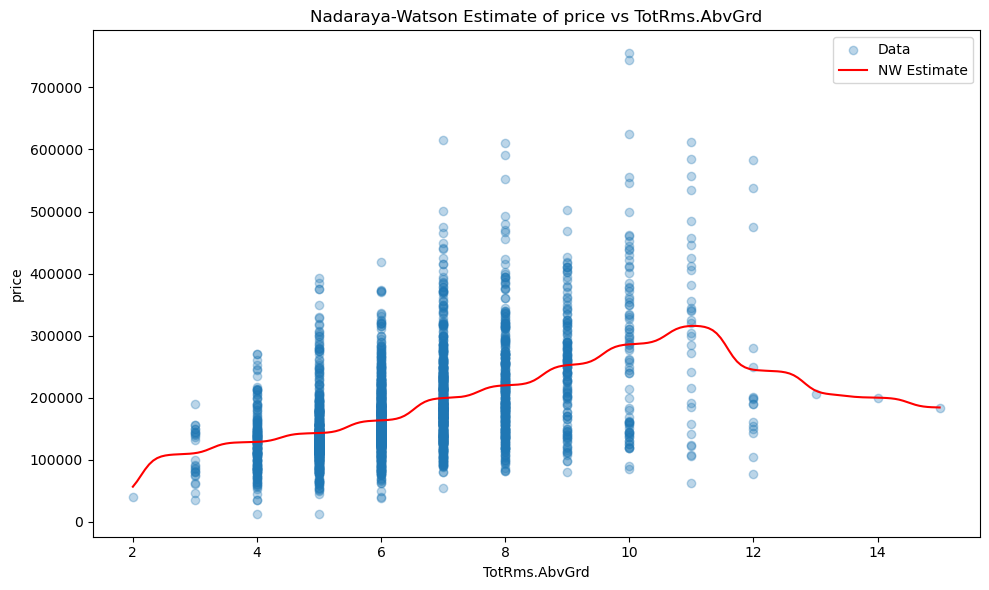

In [145]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['TotRms.AbvGrd'], df['price'], alpha=0.3, label='Data')
plt.plot(x_grid, y_est, color='red', label='NW Estimate')
plt.title('Nadaraya-Watson Estimate of price vs TotRms.AbvGrd')
plt.xlabel('TotRms.AbvGrd')
plt.ylabel('price')
plt.legend()
plt.tight_layout()
plt.show()


#### Observations :

- The red NW estimate curve clearly shows a nonlinear trend: house price generally increases with the number of rooms, but not at a constant rate.

- The slope is steepest between 5 and 8 rooms, suggesting that adding rooms in this range has the most impact on price.

- After ~10 rooms, the curve flattens, indicating diminishing returns: adding more rooms doesn’t proportionally increase price.

- This could reflect market saturation—buyers may not value extra rooms beyond a certain point unless they’re high-quality or part of luxury homes.

- The scatter plot shows wide price dispersion for homes with 5–7 rooms.

- This suggests that other factors (e.g., location, quality, amenities) heavily influence price in this range, making room count alone a weak predictor.

- Very few homes have fewer than 4 or more than 10 rooms, and the NW curve becomes less stable at the edges.

- This is typical in kernel regression: estimates near the boundaries are less reliable due to fewer neighbors.

- The NW estimator provides a smooth, interpretable trend without assuming linearity.

- It’s robust to outliers and adapts to local structure, making it ideal for exploratory housing price modeling.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

Relationships between the following variables :

- X: Area (area in square feet)

- Y: Price (house sale price)

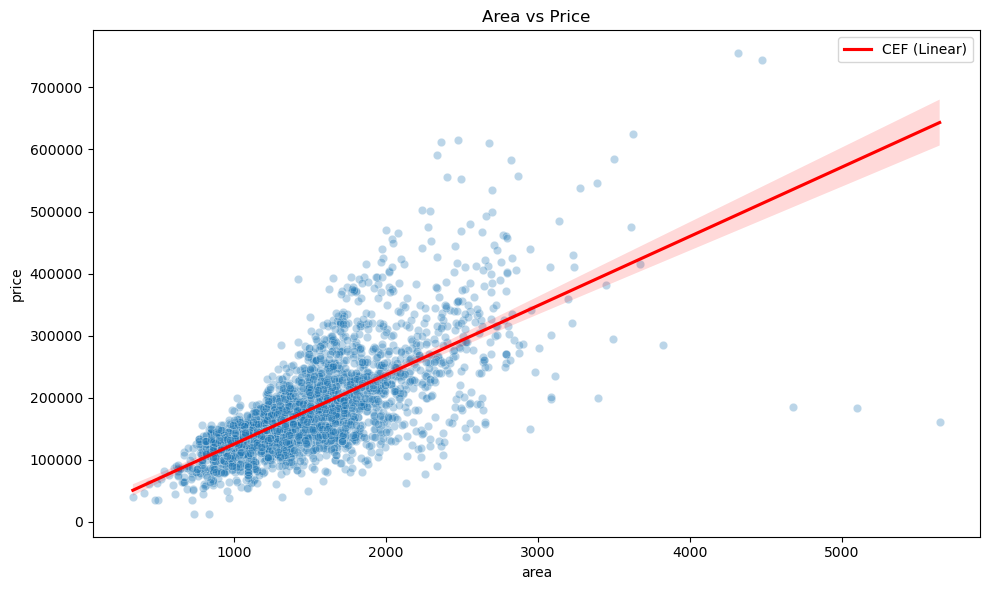

In [149]:
# Scatterplot and Conditional Expectation Function (CEF)

import matplotlib.pyplot as plt
import seaborn as sns

# Clean data
df = ames_df[['area', 'price']].dropna()

x = df['area'].values
y = df['price'].values

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.3)
sns.regplot(x=x, y=y, scatter=False, color='red', label='CEF (Linear)')
plt.title('Area vs Price')
plt.xlabel('area')
plt.ylabel('price')
plt.legend()
plt.tight_layout()
plt.show()

#### Observations :

- The plot shows a strong positive correlation between property area and sale price.

- The red regression line (CEF) captures the average trend: as area increases, price tends to rise.

- The confidence band suggests relatively stable uncertainty across the range, with some widening at the extremes.

#### Is This Relationship Causal?

> Not necessarily. While the association is clear, causal interpretation is threatened by several omitted or latent variables:

- Larger homes may also be better built, more luxurious, or newer.

- If quality increases with size, then price is responding to both — not just area.

- Area might be correlated with location: larger homes may cluster in affluent neighborhoods.

- Neighborhood drives price independently of size (e.g., school districts, amenities, safety).

- A large but outdated home may sell for less than a smaller, modern one.

- Renovation history is often unobserved or inconsistently measured.

- Buyer perception, architectural appeal, and layout efficiency can all influence price.

- These are hard to quantify but may mediate the effect of area on price.

#### Threats to Causal Identification

1. Omitted Confounders	
- Overall Quality
- Neighborhood	

> They affect both area and price

2. Latent Concepts	
- Buyer preference
- Design appeal	

> Not measured, but influence valuation

#### Why Prediction Still Works Without Causal Identification

Even if the relationship between 𝑋 and 𝑌 is not causal, your model can still be valid and useful for prediction — as long as you're not trying to intervene or manipulate the system based on that relationship.

> What Prediction Requires:
- A stable, observable pattern between 𝑋 and 𝑌
- Historical data that reflects how 𝑌 tends to behave when 𝑋 takes certain values
- No need to explain why 𝑌 changes with 𝑋 — just that it does

> What Causal Inference Requires:
- Isolation of the effect of 𝑋 on 𝑌, ruling out confounders
- A clear counterfactual: what would happen to 𝑌 if you changed 𝑋


Example: Area vs. Price in Housing
- Your model shows that larger homes tend to sell for more.
- This is a strong predictive signal: if you know the area, you can estimate the price with reasonable accuracy.
- But you can’t assume that increasing the area of a home will cause its price to rise — because other factors (quality, location, design) may be driving both.


If you intervene — say, by adding 500 sq ft to a home — the model’s prediction may no longer hold:
- The added space might not be usable or desirable.
- It could violate zoning laws or reduce yard space.
- Buyers might not value it the same way as organically larger homes.

In short: the model reflects correlation, not guaranteed outcomes under manipulation.

#### In short

- You can use your model to predict 𝑌 given 𝑋 as long as you're observing the system, not changing it.